In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [6]:
df = pd.read_csv("../feature-engineering/output/dataset_churn.csv")
df.head()

,cliente_id,total_atendimentos,total_gasto,ticket_medio,dias_desde_ultimo_atendimento,intervalo_medio_atendimentos,atendimentos_30d,atendimentos_90d,gasto_90d,quantidade_servicos_diferentes,quantidade_profissionais_diferentes,target_churn
0,mock-cli-00001,1,162.48,162.48,99,0.00,0,0,0.00,1,1,1
1,mock-cli-00002,7,1495.73,213.68,3,61.50,1,2,147.79,8,5,0
2,mock-cli-00003,0,0.00,0.00,-1,0.00,0,0,0.00,0,0,1
3,mock-cli-00004,0,0.00,0.00,-1,0.00,0,0,0.00,0,0,1
4,mock-cli-00005,7,1208.66,172.67,1,53.67,1,2,811.75,7,5,0


In [3]:
df.shape

(500, 12)

In [4]:
df.columns

Index(['cliente_id', 'total_atendimentos', 'total_gasto', 'ticket_medio',
       'dias_desde_ultimo_atendimento', 'intervalo_medio_atendimentos',
       'atendimentos_30d', 'atendimentos_90d', 'gasto_90d',
       'quantidade_servicos_diferentes', 'quantidade_profissionais_diferentes',
       'target_churn'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   cliente_id                           500 non-null    str    
 1   total_atendimentos                   500 non-null    int64  
 2   total_gasto                          500 non-null    float64
 3   ticket_medio                         500 non-null    float64
 4   dias_desde_ultimo_atendimento        500 non-null    int64  
 5   intervalo_medio_atendimentos         500 non-null    float64
 6   atendimentos_30d                     500 non-null    int64  
 7   atendimentos_90d                     500 non-null    int64  
 8   gasto_90d                            500 non-null    float64
 9   quantidade_servicos_diferentes       500 non-null    int64  
 10  quantidade_profissionais_diferentes  500 non-null    int64  
 11  target_churn                         500 no

In [6]:
df.describe()

,total_atendimentos,total_gasto,ticket_medio,dias_desde_ultimo_atendimento,intervalo_medio_atendimentos,atendimentos_30d,atendimentos_90d,gasto_90d,quantidade_servicos_diferentes,quantidade_profissionais_diferentes,target_churn
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,2.788000,546.305920,130.097360,36.904000,34.683480,0.366000,0.968000,195.482940,3.398000,2.308000,0.348000
std,2.945574,702.096239,120.422077,53.107472,39.309818,0.494503,1.008469,287.521517,3.540716,2.227793,0.476813
min,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,271.015000,125.120000,18.000000,31.320000,0.000000,1.000000,76.360000,2.000000,2.000000,0.000000
75%,4.000000,806.085000,190.972500,49.000000,59.500000,1.000000,2.000000,267.477500,5.000000,4.000000,1.000000
max,14.000000,3886.820000,813.750000,350.000000,244.000000,2.000000,4.000000,1807.730000,17.000000,10.000000,1.000000


In [7]:
df.isnull().sum()

cliente_id                             0
total_atendimentos                     0
total_gasto                            0
ticket_medio                           0
dias_desde_ultimo_atendimento          0
intervalo_medio_atendimentos           0
atendimentos_30d                       0
atendimentos_90d                       0
gasto_90d                              0
quantidade_servicos_diferentes         0
quantidade_profissionais_diferentes    0
target_churn                           0
dtype: int64

In [8]:
df["target_churn"].value_counts()

target_churn
0    326
1    174
Name: count, dtype: int64

In [9]:
df["target_churn"].value_counts(normalize=True)*100

target_churn
0    65.2
1    34.8
Name: proportion, dtype: float64

Text(0, 0.5, 'Quantidade de clientes')

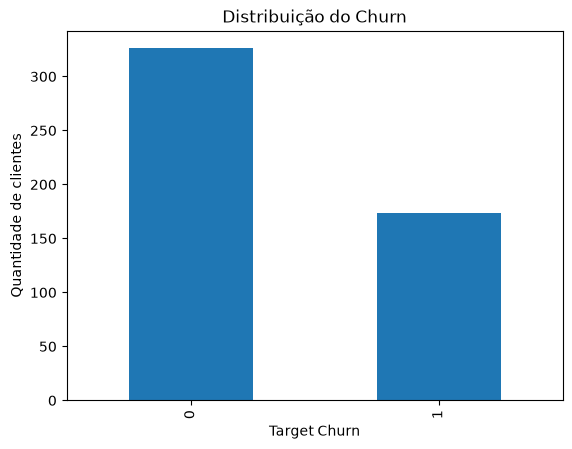

In [10]:
df["target_churn"].value_counts().plot(kind="bar")

plt.title("Distribuição do Churn")
plt.xlabel("Target Churn")
plt.ylabel("Quantidade de clientes")

In [12]:
df.groupby("target_churn")["total_atendimentos"].mean()

target_churn
0    3.177914
1    2.057471
Name: total_atendimentos, dtype: float64

In [13]:
df.groupby("target_churn")[
    [
        "total_atendimentos",
        "total_gasto",
        "ticket_medio",
        "dias_desde_ultimo_atendimento",
        "atendimentos_30d",
        "atendimentos_90d",
        "gasto_90d"
    ]
].mean()

,total_atendimentos,total_gasto,ticket_medio,dias_desde_ultimo_atendimento,atendimentos_30d,atendimentos_90d,gasto_90d
target_churn,,,,,,,
0,3.177914,647.098681,138.518466,33.481595,0.407975,1.141104,243.986595
1,2.057471,357.464310,114.319885,43.316092,0.287356,0.643678,104.608276


## 5. Análise das Features por Churn

In [7]:
df.groupby("target_churn")[
    [
        "total_atendimentos",
        "total_gasto",
        "ticket_medio",
        "dias_desde_ultimo_atendimento",
        "intervalo_medio_atendimentos",
        "atendimentos_30d",
        "atendimentos_90d",
        "gasto_90d",
        "quantidade_servicos_diferentes",
        "quantidade_profissionais_diferentes"
    ]
].mean()

,total_atendimentos,total_gasto,ticket_medio,dias_desde_ultimo_atendimento,intervalo_medio_atendimentos,atendimentos_30d,atendimentos_90d,gasto_90d,quantidade_servicos_diferentes,quantidade_profissionais_diferentes
target_churn,,,,,,,,,,
0,3.177914,647.098681,138.518466,33.481595,32.786595,0.407975,1.141104,243.986595,3.880368,2.561350
1,2.057471,357.464310,114.319885,43.316092,38.237414,0.287356,0.643678,104.608276,2.494253,1.833333


## 6. Distribuição das Features por Churn


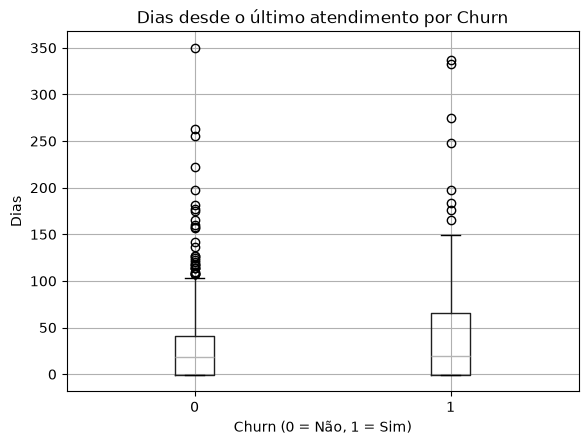

In [8]:
df.boxplot(
    column="dias_desde_ultimo_atendimento",
    by="target_churn"
)
plt.title("Dias desde o último atendimento por Churn")
plt.suptitle("")
plt.xlabel("Churn (0 = Não, 1 = Sim)")
plt.ylabel("Dias")

plt.show()

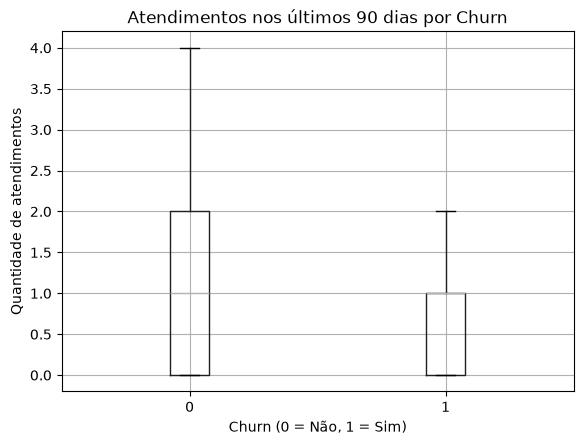

In [9]:
df.boxplot(
    column="atendimentos_90d",
    by="target_churn"
)

plt.title("Atendimentos nos últimos 90 dias por Churn")
plt.suptitle("")
plt.xlabel("Churn (0 = Não, 1 = Sim)")
plt.ylabel("Quantidade de atendimentos")

plt.show()

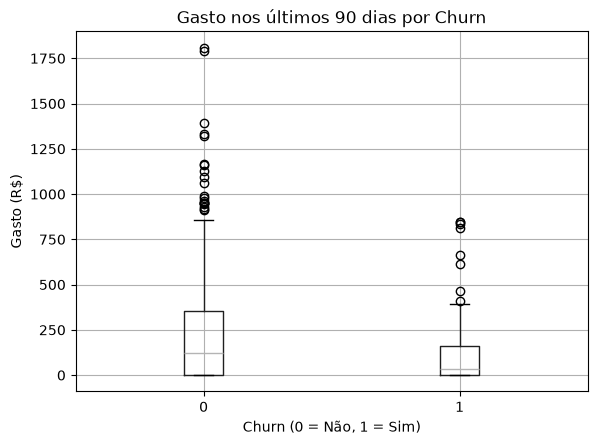

In [10]:
df.boxplot(
    column="gasto_90d",
    by="target_churn"
)

plt.title("Gasto nos últimos 90 dias por Churn")
plt.suptitle("")
plt.xlabel("Churn (0 = Não, 1 = Sim)")
plt.ylabel("Gasto (R$)")

plt.show()

In [11]:
features_principais = [
    "dias_desde_ultimo_atendimento",
    "atendimentos_90d",
    "gasto_90d"
]

df.groupby("target_churn")[features_principais].agg(
    ["mean", "median", "min", "max"]
)

dias_desde_ultimo_atendimento                 atendimentos_90d  \
                                      mean median min  max             mean   
target_churn                                                                  
0                                33.481595   18.0  -1  350         1.141104   
1                                43.316092   20.0  -1  337         0.643678   

                              gasto_90d                         
             median min max        mean   median  min      max  
target_churn                                                    
0               1.0   0   4  243.986595  124.220  0.0  1807.73  
1               1.0   0   2  104.608276   34.175  0.0   843.87

In [12]:
df.groupby("target_churn")[features_principais].mean().round(2)

,dias_desde_ultimo_atendimento,atendimentos_90d,gasto_90d
target_churn,,,
0,33.48,1.14,243.99
1,43.32,0.64,104.61


In [13]:
medias = df.groupby("target_churn")[features_principais].mean()

comparacao = (
    (medias.loc[1] - medias.loc[0])
    / medias.loc[0]
) * 100

comparacao.round(2)

dias_desde_ultimo_atendimento    29.37
atendimentos_90d                -43.59
gasto_90d                       -57.13
dtype: float64

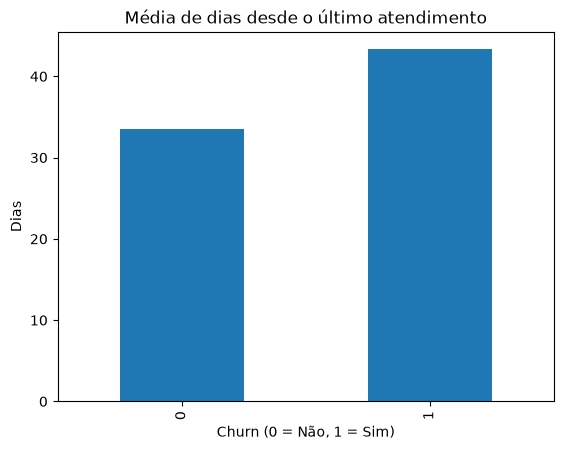

In [14]:
df.groupby("target_churn")[
    "dias_desde_ultimo_atendimento"
].mean().plot(kind="bar")

plt.title("Média de dias desde o último atendimento")
plt.xlabel("Churn (0 = Não, 1 = Sim)")
plt.ylabel("Dias")

plt.show()

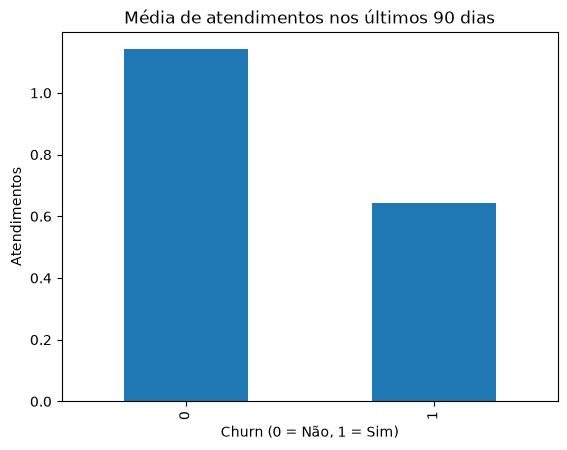

In [15]:
df.groupby("target_churn")[
    "atendimentos_90d"
].mean().plot(kind="bar")

plt.title("Média de atendimentos nos últimos 90 dias")
plt.xlabel("Churn (0 = Não, 1 = Sim)")
plt.ylabel("Atendimentos")

plt.show()

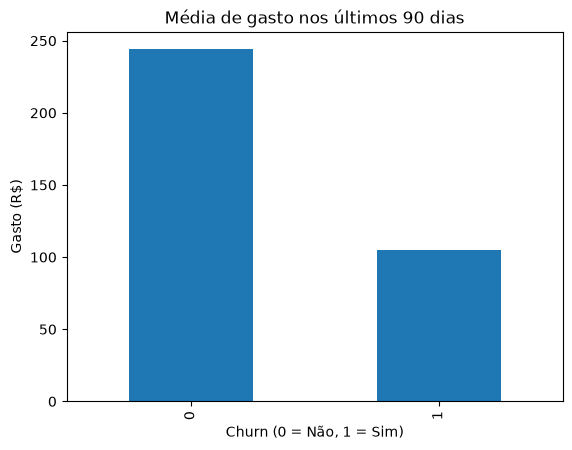

In [16]:
df.groupby("target_churn")[
    "gasto_90d"
].mean().plot(kind="bar")

plt.title("Média de gasto nos últimos 90 dias")
plt.xlabel("Churn (0 = Não, 1 = Sim)")
plt.ylabel("Gasto (R$)")

plt.show()

In [17]:
correlacao =df[
    features_principais + ["target_churn"]
].corr()

correlacao.round(2)

,dias_desde_ultimo_atendimento,atendimentos_90d,gasto_90d,target_churn
dias_desde_ultimo_atendimento,1.00,-0.21,-0.17,0.09
atendimentos_90d,-0.21,1.00,0.79,-0.24
gasto_90d,-0.17,0.79,1.00,-0.23
target_churn,0.09,-0.24,-0.23,1.00
